# Santander

## Importar librerías

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import math
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [2]:
# 1. leer normal (una sola cabecera)
df = pd.read_csv("../csv/santander_enriched_scaled.csv")


def preparar_datos_multivariados(df, target_col="SAN_Adj_Close", window_size=30):
    features = df.drop(columns=[target_col])
    target = df[[target_col]]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(features)
    y_scaled = scaler_y.fit_transform(target)

    X, y = [], []
    for i in range(window_size, len(X_scaled)):
        X.append(X_scaled[i-window_size:i])
        y.append(y_scaled[i, 0])

    X = np.array(X)
    y = np.array(y)
    return X, y, scaler_X, scaler_y

## PREPROCESAMIENTO

In [3]:
def preparar_datos_multivariados(df, target_col="SAN_Adj_Close", window_size=30):
    df = df.sort_values("Date").reset_index(drop=True)

    features = df.drop(columns=["Date", target_col])
    target = df[[target_col]]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(features)
    y_scaled = scaler_y.fit_transform(target)

    X, y = [], []
    for i in range(window_size, len(X_scaled)):
        X.append(X_scaled[i-window_size:i, :])  # todas las features
        y.append(y_scaled[i, 0])

    X = np.array(X)
    y = np.array(y)
    return X, y, scaler_X, scaler_y

X, y, scaler_X, scaler_y = preparar_datos_multivariados(df, target_col="SAN_Adj_Close", window_size=30)
print(X.shape, y.shape)



(5382, 30, 8) (5382,)


## Train y test temporal

In [4]:
# 80% train, 20% test (temporal, sin shuffle)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (4305, 30, 8) (4305,)
Test : (1077, 30, 8) (1077,)


## Modelos

In [5]:
def build_rnn(window_size, n_features):
    model = Sequential([
        SimpleRNN(64, input_shape=(window_size, n_features)),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_lstm(window_size, n_features):
    model = Sequential([
        LSTM(64, input_shape=(window_size, n_features)),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_gru(window_size, n_features):
    model = Sequential([
        GRU(64, input_shape=(window_size, n_features)),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

## Entrenamiento

In [6]:
# ==============================
# CONFIGURACIÓN BASE
# ==============================
EPOCHS_DEFAULT = 1000   # para RNN y GRU
EPOCHS_LSTM = 1000     # para LSTM
BATCH = 32
window_size = 30

# Crear carpeta 'modelos' fuera de notebooks si no existe
modelos_dir = os.path.join("..", "modelos")
os.makedirs(modelos_dir, exist_ok=True)

# ==============================
# FUNCIÓN DE ENTRENAMIENTO
# ==============================
def entrenar_modelo(nombre, build_fn, X_train, y_train, X_test, y_test, window_size):
    """
    Entrena un modelo (RNN, LSTM o GRU) con EarlyStopping y ModelCheckpoint.
    """
    print(f"\n🧠 Entrenando modelo {nombre}...\n")
    n_features = X_train.shape[2]   # <- número real de columnas de entrada
    model = build_fn(window_size, n_features)

    # Ruta completa donde guardar el modelo
    model_path = os.path.join(modelos_dir, f"mejor_{nombre.lower()}_santander.h5")

    # Configurar callbacks
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=150 if nombre != "LSTM" else 400,  # más paciencia para LSTM
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

    # Número de épocas dinámico
    epochs = EPOCHS_LSTM if nombre == "LSTM" else EPOCHS_DEFAULT

    # Entrenamiento
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=BATCH,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    print(f"✅ Modelo {nombre} finalizado ({len(history.history['loss'])} epochs entrenadas)")
    return model, history

# ==============================
# ENTRENAR LOS TRES MODELOS
# ==============================

rnn_model,  hist_rnn  = entrenar_modelo("RNN",  build_rnn,  X_train, y_train, X_test, y_test, window_size)
lstm_model, hist_lstm = entrenar_modelo("LSTM", build_lstm, X_train, y_train, X_test, y_test, window_size)
gru_model,  hist_gru  = entrenar_modelo("GRU",  build_gru,  X_train, y_train, X_test, y_test, window_size)




🧠 Entrenando modelo RNN...

Epoch 1/1000


c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


130/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1304
Epoch 1: val_loss improved from None to 0.03760, saving model to ..\modelos\mejor_rnn_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0483 - val_loss: 0.0376
Epoch 2/1000
119/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0099
Epoch 2: val_loss improved from 0.03760 to 0.02087, saving model to ..\modelos\mejor_rnn_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0084 - val_loss: 0.0209
Epoch 3/1000
112/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053
Epoch 3: val_loss improved from 0.02087 to 0.01481, saving model to ..\modelos\mejor_rnn_santander.h5


...

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.2410e-04 - val_loss: 0.0013
Epoch 20/1000
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4621e-04
Epoch 20: val_loss did not improve from 0.00130
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.0472e-04 - val_loss: 0.0038
Epoch 21/1000
128/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3140e-04
Epoch 21: val_loss did not improve from 0.00130
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.3843e-04 - val_loss: 0.0037
Epoch 22/1000
130/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2571e-04
Epoch 22: val_loss did not improve from 0.00130
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.2879e-04 - val_loss: 0.0045
Epoch 23/1000
130/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9766e-04
Epoch 23: val_loss did not improve from 0.00130
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.0174e-04 - val_loss: 0.0027
Epoch 24/1000
128/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0998e-04
Epoch 24: val_loss did not improve from 0.0

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0137e-04 - val_loss: 0.0012
Epoch 28/1000
126/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6154e-04
Epoch 28: val_loss did not improve from 0.00117
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.5490e-04 - val_loss: 0.0030
Epoch 29/1000
128/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5263e-04
Epoch 29: val_loss did not improve from 0.00117
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.6606e-04 - val_loss: 0.0013
Epoch 30/1000
126/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7074e-04
Epoch 30: val_loss did not improve from 0.00117
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.5848e-04 - val_loss: 0.0012
Epoch 31/1000
127/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4777e-04
Epoch 31: val_loss improved from 0.00117 to 0.00105, saving model to ..\modelos\mejor_gru_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.5020e-04 - val_loss: 0.0010
Epoch 32/1000
126/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5062e-04
Epoch 32: val_loss did not improve from 0.00105
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.3766e-04 - val_loss: 0.0014
Epoch 33/1000
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5104e-04
Epoch 33: val_loss did not improve from 0.00105
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.3407e-04 - val_loss: 0.0017
Epoch 34/1000
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6651e-04
Epoch 34: val_loss did not improve from 0.00105
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2558e-04 - val_loss: 0.0014
Epoch 35/1000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1335e-04
Epoch 35: val_loss improved from 0.00105 to 0.00077, saving model to ..\modelos\mejor_gru_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2383e-04 - val_loss: 7.7475e-04
Epoch 36/1000
127/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3294e-04
Epoch 36: val_loss did not improve from 0.00077
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.3253e-04 - val_loss: 0.0011
Epoch 37/1000
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9465e-04
Epoch 37: val_loss improved from 0.00077 to 0.00069, saving model to ..\modelos\mejor_gru_santander.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9807e-04 - val_loss: 6.9225e-04
Epoch 38/1000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1840e-04
Epoch 38: val_loss did not improve from 0.00069
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.0543e-04 - val_loss: 7.2261e-04
Epoch 39/1000
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2997e-04
Epoch 39: val_loss did not improve from 0.00069
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2003e-04 - val_loss: 0.0013
Epoch 40/1000
127/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2046e-04
Epoch 40: val_loss did not improve from 0.00069
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1440e-04 - val_loss: 9.0108e-04
Epoch 41/1000
127/135 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0383e-04
Epoch 41: val_loss did not improve from 0.00069
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.1205e-04 - val_loss: 0.0015
Epoch 42/1000
129/135 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3445e-04
Epoch 42: val_loss did not impr

# todas con la misma forma de entrada
input_shape = (window_size, 1)

def build_rnn():
    model = Sequential([
        SimpleRNN(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_lstm():
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_gru():
    model = Sequential([
        GRU(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

## Predicciones

In [7]:
# predicciones (todavía en escala 0-1 porque el modelo se entrenó así)
y_pred_rnn  = rnn_model.predict(X_test)
y_pred_lstm = lstm_model.predict(X_test)
y_pred_gru  = gru_model.predict(X_test)

# desescalar la y real
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# desescalar las predicciones
pred_rnn_real  = scaler_y.inverse_transform(y_pred_rnn)
pred_lstm_real = scaler_y.inverse_transform(y_pred_lstm)
pred_gru_real  = scaler_y.inverse_transform(y_pred_gru)



34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


## Métricas

In [8]:
def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_rnn, rmse_rnn   = evaluar(y_test_real, pred_rnn_real)
mae_lstm, rmse_lstm = evaluar(y_test_real, pred_lstm_real)
mae_gru, rmse_gru   = evaluar(y_test_real, pred_gru_real)

print("RNN  -> MAE:", mae_rnn,  "RMSE:", rmse_rnn)
print("LSTM -> MAE:", mae_lstm, "RMSE:", rmse_lstm)
print("GRU  -> MAE:", mae_gru,  "RMSE:", rmse_gru)


RNN  -> MAE: 0.04921480755005759 RMSE: 0.0764995902105106
LSTM -> MAE: 0.01705665328061593 RMSE: 0.02416574770449498
GRU  -> MAE: 0.021969961449181483 RMSE: 0.02631065887132126


# Graficar

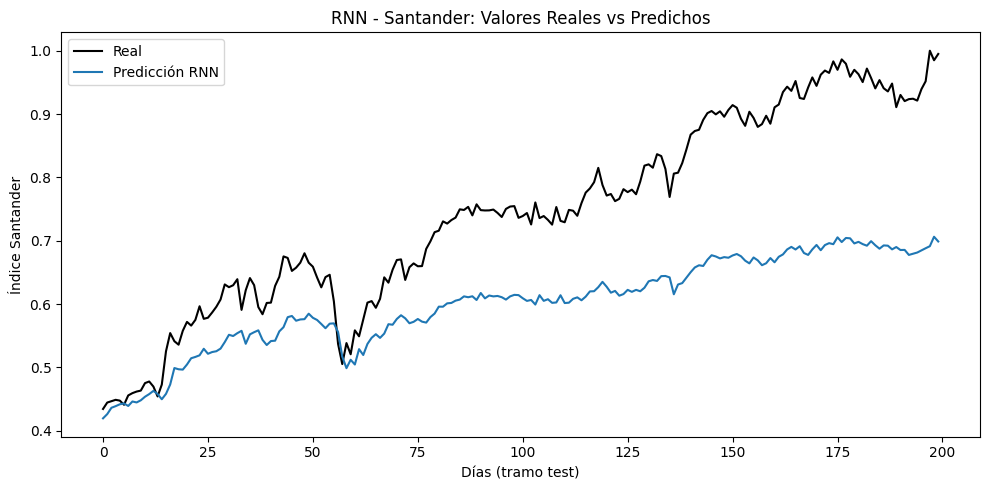

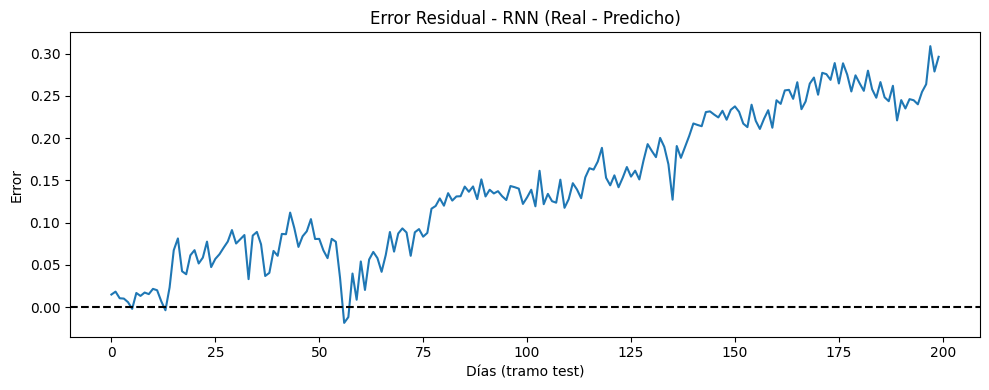

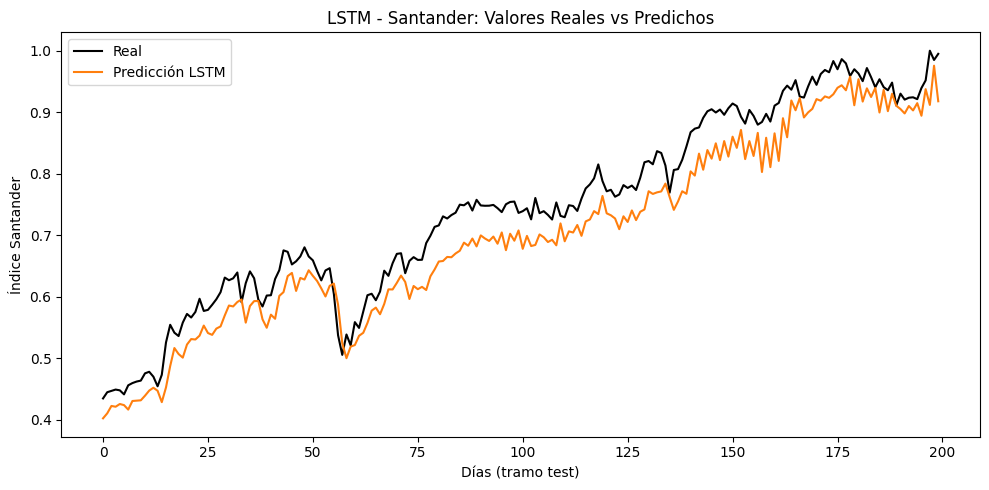

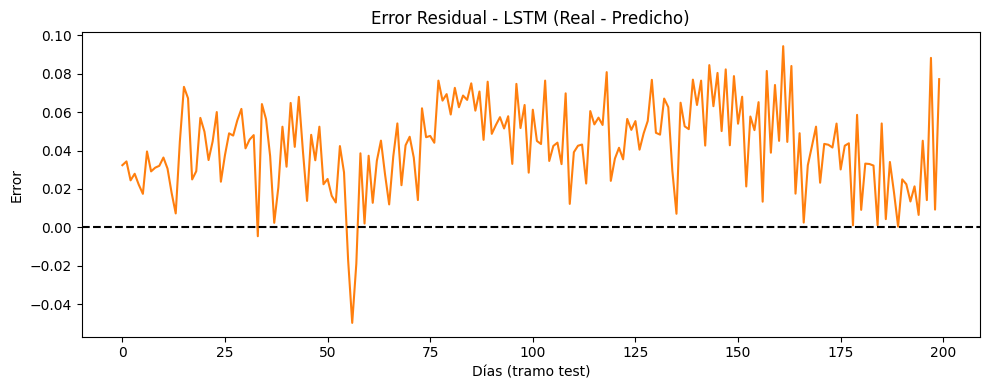

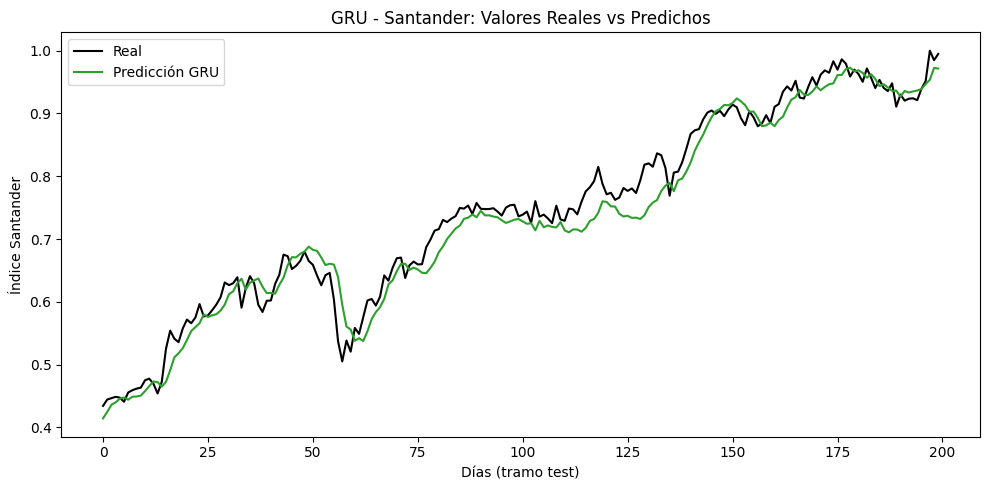

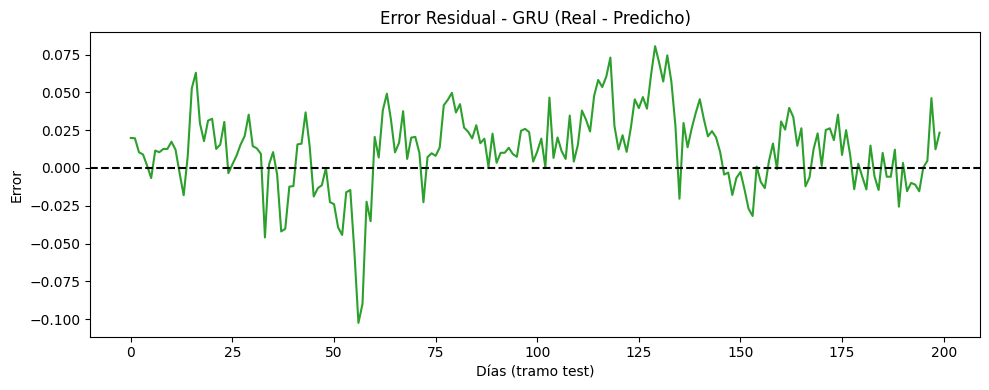

In [9]:
# --- Tramo a mostrar (últimos 200 días del test, por ejemplo) ---
n_mostrar = 200
y_real_plot = y_test_real[-n_mostrar:]
pred_rnn_plot  = pred_rnn_real[-n_mostrar:]
pred_lstm_plot = pred_lstm_real[-n_mostrar:]
pred_gru_plot  = pred_gru_real[-n_mostrar:]

# ===============================
# 1️⃣ RNN
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_rnn_plot, label="Predicción RNN", color="tab:blue")
plt.title("RNN - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error RNN ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_rnn_plot, color="tab:blue")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - RNN (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# ===============================
# 2️⃣ LSTM
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_lstm_plot, label="Predicción LSTM", color="tab:orange")
plt.title("LSTM - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error LSTM ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_lstm_plot, color="tab:orange")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - LSTM (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# ===============================
# 3️⃣ GRU
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_gru_plot, label="Predicción GRU", color="tab:green")
plt.title("GRU - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error GRU ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_gru_plot, color="tab:green")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - GRU (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()


## Predecir dias futuros

In [ ]:
def predecir_siguiente_multivariante(model, df_original, scaler_X, scaler_y, target_col="SAN_Adj_Close", window_size=30):
    """
    Predice el siguiente valor del target_col usando todas las features del dataset.
    """
    # Asegurarnos de tener las columnas ordenadas igual que durante el entrenamiento
    features = df_original.drop(columns=["Date", target_col])

    # 1️⃣ Tomamos los últimos window_size días de features
    ultimos = features.values[-window_size:]
    
    # 2️⃣ Escalamos las features con el scaler_X
    ultimos_scaled = scaler_X.transform(ultimos)

    # 3️⃣ Damos la forma adecuada al modelo (1 muestra, window_size pasos, n_features)
    X_input = ultimos_scaled.reshape((1, window_size, features.shape[1]))

    # 4️⃣ Predicción en escala 0–1
    pred_scaled = model.predict(X_input)

    # 5️⃣ Desescalar al valor real del precio
    pred_real = scaler_y.inverse_transform(pred_scaled)

    return pred_real[0, 0]



In [11]:
pred_manana_lstm = predecir_siguiente_multivariante(
    lstm_model,
    df,             # tu dataframe limpio y completo (con Date, SAN_Adj_Close, IBEX, etc.)
    scaler_X,
    scaler_y,
    target_col="SAN_Adj_Close",
    window_size=window_size
)

print(f"Predicción Santander próximo día (LSTM): {pred_manana_lstm:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicción Santander próximo día (LSTM): 0.9570


c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [12]:
def predecir_n_dias_multivariante(model, df_original, scaler_X, scaler_y,
                                  target_col="SAN_Adj_Close", window_size=30, n_dias=5):
    # trabajamos con las mismas columnas que en el entrenamiento
    features = df_original.drop(columns=["Date", target_col])

    # tomamos los últimos window_size días de features
    ultimos_feat = features.values[-window_size:]  # (30, n_features)

    # lista donde guardaremos las predicciones desescaladas
    preds_reales = []

    # copia de trabajo de la ventana (en escala 0-1)
    ventana_scaled = scaler_X.transform(ultimos_feat)  # (30, n_features)

    for _ in range(n_dias):
        # (1, pasos, n_features)
        X_input = ventana_scaled.reshape((1, window_size, features.shape[1]))
        pred_scaled = model.predict(X_input, verbose=0)          # (1, 1)
        pred_real = scaler_y.inverse_transform(pred_scaled)[0,0] # float real
        preds_reales.append(pred_real)

        # ahora necesitamos actualizar la ventana con la predicción
        # pero ojo: la ventana tiene todas las features, y solo conocemos el target
        # lo más simple: mantenemos las features pasadas y solo metemos el target nuevo en su sitio

        # reconstruimos la última fila de features para el futuro:
        # usamos la última fila real de features (la más reciente)
        ultima_fila_real = features.values[-1:].copy()  # (1, n_features)
        # sustituimos en esa fila la columna del target por la predicción escalada
        # primero escalamos el valor predicho de nuevo para colocarlo en la ventana
        pred_scaled_full = scaler_y.transform(pred_scaled)[0,0]

        # buscamos el índice de la columna target en features+target
        # pero como en features NO está el target, tenemos que construir la fila futura así:
        # -> usamos la última fila real de features (sin target), y solo actualizamos más adelante.
        # actualizamos la ventana: quitamos la primera fila y agregamos la nueva fila de features escalada
        nueva_fila_feat_scaled = scaler_X.transform(ultima_fila_real)  # (1, n_features)
        # la ventana pasa a ser: desde la fila 1 hasta el final + nueva fila
        ventana_scaled = np.vstack([ventana_scaled[1:], nueva_fila_feat_scaled])

    return preds_reales


In [13]:
# asegurarnos de que la columna Date es datetime
df["Date"] = pd.to_datetime(df["Date"])

# 1) predecimos 5 días
preds_5 = predecir_n_dias_multivariante(
    lstm_model,
    df,
    scaler_X,
    scaler_y,
    target_col="SAN_Adj_Close",
    window_size=window_size,
    n_dias=5
)

# 2) generar 5 fechas futuras (días laborables)
ultima_fecha = df["Date"].max()              # ahora sí es Timestamp
fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=5,
    freq="B"  # solo días hábiles
)

df_futuro = pd.DataFrame({
    "Date": fechas_futuras,
    "Predicted_SAN_Adj_Close": preds_5
})

# 3) histórico de 1 mes
historico_plot = df[["Date", "SAN_Adj_Close"]].tail(30).copy()


c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\

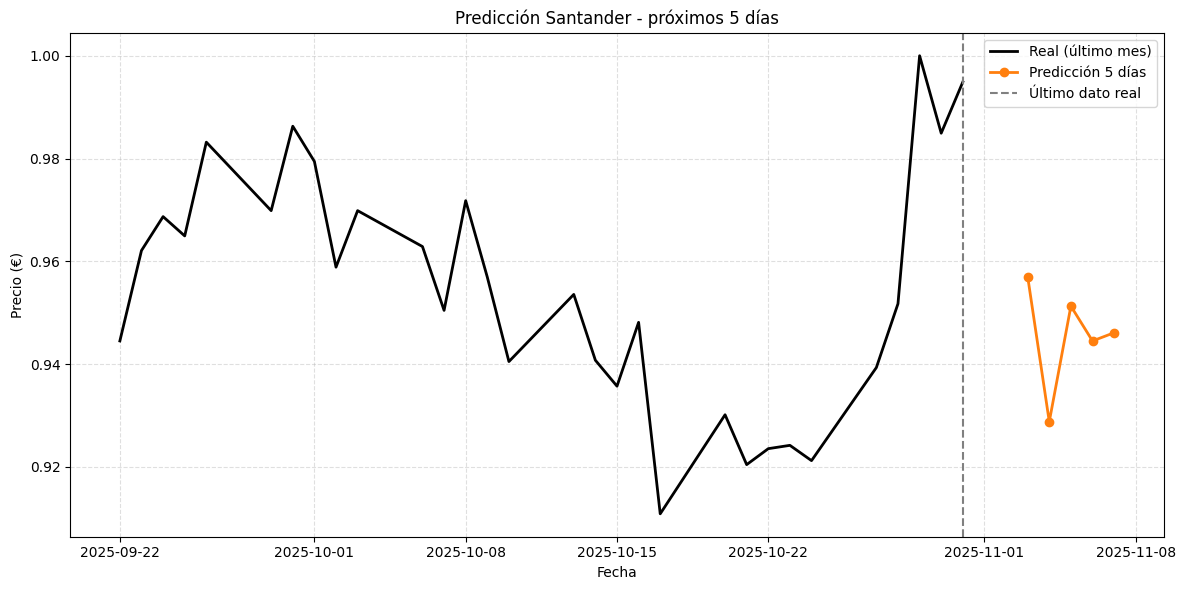

In [14]:
plt.figure(figsize=(12,6))

# histórico
plt.plot(historico_plot["Date"], historico_plot["SAN_Adj_Close"],
         label="Real (último mes)", color="black", linewidth=2)

# futuro
plt.plot(df_futuro["Date"], df_futuro["Predicted_SAN_Adj_Close"],
         label="Predicción 5 días", color="tab:orange", marker="o", linewidth=2)

# línea de corte
plt.axvline(historico_plot["Date"].max(), color="gray", linestyle="--", label="Último dato real")

plt.title("Predicción Santander - próximos 5 días")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")

# 2 decimales en eje Y
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



In [15]:
pred_manana_gru = predecir_siguiente_multivariante(
    gru_model,
    df,             # tu dataframe limpio y completo (con Date, SAN_Adj_Close, IBEX, etc.)
    scaler_X,
    scaler_y,
    target_col="SAN_Adj_Close",
    window_size=window_size
)

print(f"Predicción Santander próximo día (GRU): {pred_manana_gru:.4f}")

c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicción Santander próximo día (GRU): 0.9804


In [16]:
def predecir_n_dias_multivariante(model, df_original, scaler_X, scaler_y,
                                  target_col="SAN_Adj_Close", window_size=30, n_dias=5):
    # trabajamos con las mismas columnas que en el entrenamiento
    features = df_original.drop(columns=["Date", target_col])

    # tomamos los últimos window_size días de features
    ultimos_feat = features.values[-window_size:]  # (30, n_features)

    # lista donde guardaremos las predicciones desescaladas
    preds_reales = []

    # copia de trabajo de la ventana (en escala 0-1)
    ventana_scaled = scaler_X.transform(ultimos_feat)  # (30, n_features)

    for _ in range(n_dias):
        # (1, pasos, n_features)
        X_input = ventana_scaled.reshape((1, window_size, features.shape[1]))
        pred_scaled = model.predict(X_input, verbose=0)          # (1, 1)
        pred_real = scaler_y.inverse_transform(pred_scaled)[0,0] # float real
        preds_reales.append(pred_real)

        # ahora necesitamos actualizar la ventana con la predicción
        # pero ojo: la ventana tiene todas las features, y solo conocemos el target
        # lo más simple: mantenemos las features pasadas y solo metemos el target nuevo en su sitio

        # reconstruimos la última fila de features para el futuro:
        # usamos la última fila real de features (la más reciente)
        ultima_fila_real = features.values[-1:].copy()  # (1, n_features)
        # sustituimos en esa fila la columna del target por la predicción escalada
        # primero escalamos el valor predicho de nuevo para colocarlo en la ventana
        pred_scaled_full = scaler_y.transform(pred_scaled)[0,0]

        # buscamos el índice de la columna target en features+target
        # pero como en features NO está el target, tenemos que construir la fila futura así:
        # -> usamos la última fila real de features (sin target), y solo actualizamos más adelante.
        # actualizamos la ventana: quitamos la primera fila y agregamos la nueva fila de features escalada
        nueva_fila_feat_scaled = scaler_X.transform(ultima_fila_real)  # (1, n_features)
        # la ventana pasa a ser: desde la fila 1 hasta el final + nueva fila
        ventana_scaled = np.vstack([ventana_scaled[1:], nueva_fila_feat_scaled])

    return preds_reales

In [17]:
# asegurarnos de que la columna Date es datetime
df["Date"] = pd.to_datetime(df["Date"])

# 1) predecimos 5 días
preds_5 = predecir_n_dias_multivariante(
    gru_model,
    df,
    scaler_X,
    scaler_y,
    target_col="SAN_Adj_Close",
    window_size=window_size,
    n_dias=5
)

# 2) generar 5 fechas futuras (días laborables)
ultima_fecha = df["Date"].max()              # ahora sí es Timestamp
fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=5,
    freq="B"  # solo días hábiles
)

df_futuro = pd.DataFrame({
    "Date": fechas_futuras,
    "Predicted_SAN_Adj_Close": preds_5
})

# 3) histórico de 1 mes
historico_plot = df[["Date", "SAN_Adj_Close"]].tail(30).copy()

c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Usuario\OneDrive\Documentos\GitHub\

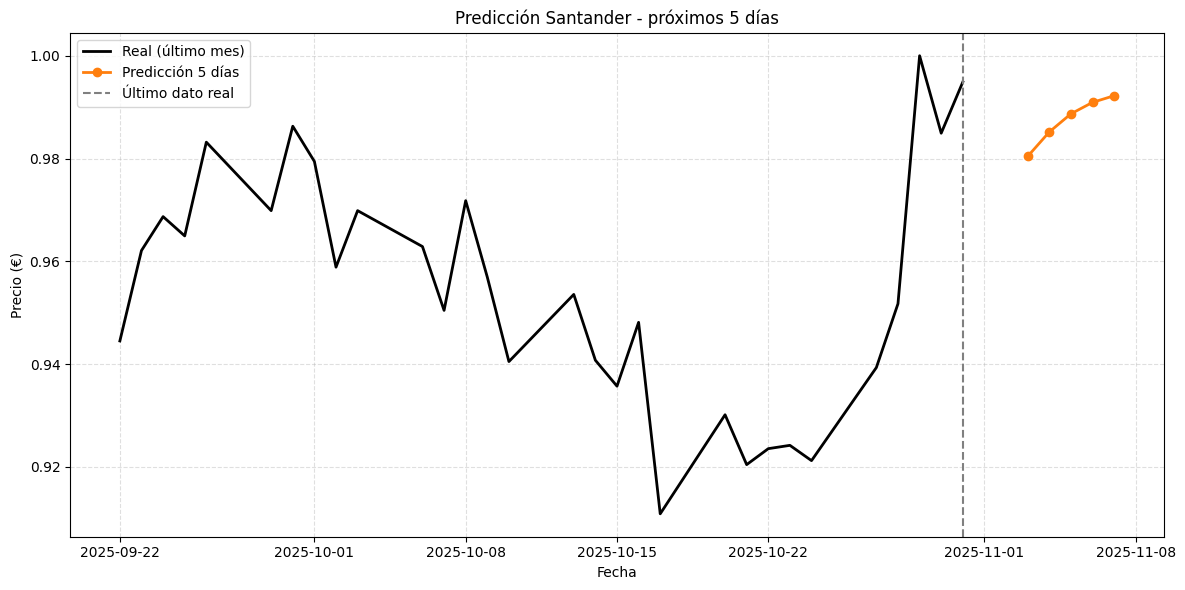

In [18]:

plt.figure(figsize=(12,6))

# histórico
plt.plot(historico_plot["Date"], historico_plot["SAN_Adj_Close"],
         label="Real (último mes)", color="black", linewidth=2)

# futuro
plt.plot(df_futuro["Date"], df_futuro["Predicted_SAN_Adj_Close"],
         label="Predicción 5 días", color="tab:orange", marker="o", linewidth=2)

# línea de corte
plt.axvline(historico_plot["Date"].max(), color="gray", linestyle="--", label="Último dato real")

plt.title("Predicción Santander - próximos 5 días")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")

# 2 decimales en eje Y
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd

# 1) leer sin cabecera
df_raw = pd.read_csv("../csv/santander_data.csv", header=None)

# 2) la primera fila tiene los nombres buenos
column_names = df_raw.iloc[0].tolist()

# 3) nos quedamos con los datos reales (a partir de la fila 3 -> índice 3)
df_real = df_raw.iloc[3:].reset_index(drop=True)

# 4) poner nombres
df_real.columns = column_names

# 5) renombrar 'Price' -> 'Date' porque en realidad es la fecha
df_real = df_real.rename(columns={"Price": "Date"})

# 6) convertir Date a datetime
df_real["Date"] = pd.to_datetime(df_real["Date"])

# 7) convertir el resto a numérico
for col in df_real.columns:
    if col != "Date":
        df_real[col] = pd.to_numeric(df_real[col], errors="coerce")

# ordenar por fecha por si acaso
df_real = df_real.sort_values("Date").reset_index(drop=True)

print(df_real.head())


        Date  Adj Close     Close  Dividends      High       Low      Open  \
0 2000-01-03   2.625067  9.849401        0.0  9.987881  9.736886  9.953261   
1 2000-01-04   2.562785  9.615716        0.0  9.780161  9.529166  9.728231   
2 2000-01-05   2.500503  9.382031        0.0  9.555131  9.304136  9.433961   
3 2000-01-06   2.500503  9.382031        0.0  9.382031  9.382031  9.382031   
4 2000-01-07   2.611226  9.797471        0.0  9.823436  9.442616  9.451271   

   Stock Splits   Volume  
0           0.0  8797337  
1           0.0  8811013  
2           0.0  9333517  
3           0.0        0  
4           0.0  9603132  


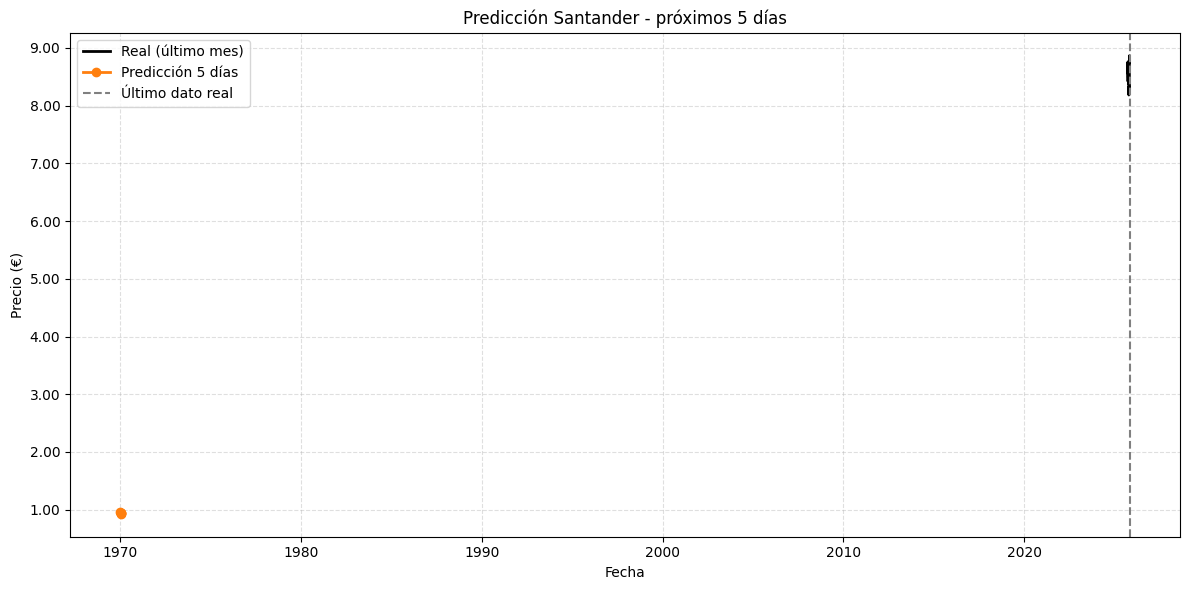

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# asegurarnos por si acaso
df_real["Date"] = pd.to_datetime(df_real["Date"])

# histórico: últimos 30 días REALES del CSV
historico_plot = df_real[["Date", "Adj Close"]].tail(30).copy()

# aquí van tus fechas futuras y predicciones (venía de antes)
# fechas_futuras = ...
# preds_5 = ...

df_futuro = pd.DataFrame({
    "Date": fechas_futuras,
    "Predicted": preds_5
})

plt.figure(figsize=(12,6))

# parte real
plt.plot(
    historico_plot["Date"],
    historico_plot["Adj Close"],
    label="Real (último mes)",
    color="black",
    linewidth=2
)

# parte futura
plt.plot(
    df_futuro["Date"],
    df_futuro["Predicted"],
    label="Predicción 5 días",
    color="tab:orange",
    marker="o",
    linewidth=2
)

# línea de corte
plt.axvline(historico_plot["Date"].max(), color="gray", linestyle="--", label="Último dato real")

plt.title("Predicción Santander - próximos 5 días")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")

# 2 decimales en el eje Y
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

